# **📊 YOUTUBE TREND AND VIDEO ANALYZER PROJECT**
Author: Afrah
Focus: Data Analysis · Content Performance · Algorithmic Insights

##==============================
## 0. ENVIRONMENT SETUP
## ==============================
## Mount Google Drive and prepare the notebook environment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ==============================
## 1. PROJECT OBJECTIVE
## ==============================
## Goal:
## Analyze high-performing YouTube videos to extract patterns
## related to engagement, retention, duration, and title structure.
## The project also includes a rule-based system to evaluate
## future video ideas based on observed trends..

## ==============================
##  2. DATA LOADING & FEATURE SELECTION
## ==============================
## Load YouTube analytics export and select
## performance-relevant features for analysis

In [ ]:
import pandas as pd

df = pd.read_csv("Table_data.csv")
important_cols = [
    'Video title',
    'Video publish time',
    'Duration',
    'Views',
    'Impressions',
    'Impressions click-through rate (%)',
    'Average percentage viewed (%)',
    'Average view duration',
    'Watch time (hours)',
    'Subscribers'
]



## ==============================
## 3. DATA CLEANING & PREPROCESSING
## ==============================
## Convert time fields, remove missing values,
## prepare numerical columns for analysis and
## classify high ,medium and low performance using
## quantile-based thresholds

In [ ]:
df_core = df[important_cols]
df_core.head()
df_core['Video publish time'] = pd.to_datetime(df_core['Video publish time'])
df_core['performance_score'] = (
    df_core['Views'] * 0.4 +
    df_core['Impressions click-through rate (%)'] * 0.2 +
    df_core['Average percentage viewed (%)'] * 0.3 +
    df_core['Subscribers'] * 0.1
)
high = df_core['performance_score'].quantile(0.75)
low = df_core['performance_score'].quantile(0.25)

def label_perf(x):
    if x >= high:
        return 'High'
    elif x <= low:
        return 'Low'
    else:
        return 'Medium'

df_core['performance_label'] = df_core['performance_score'].apply(label_perf)
high_df = df_core[df_core['performance_label'] == 'High']
high_df.head()
high_df['title_length'] = high_df['Video title'].str.len()
high_df['title_length'].describe()
high_df = high_df.dropna(subset=['Video title'])


/tmp/ipykernel_1069/2373162986.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_core['Video publish time'] = pd.to_datetime(df_core['Video publish time'])
/tmp/ipykernel_1069/2373162986.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_core['performance_score'] = (
/tmp/ipykernel_1069/2373162986.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

## ==============================
## 4. TITLE KEYWORD ANALYSIS
## ==============================
## Extract frequently occurring keywords
## from high-performing video titles

In [ ]:

from collections import Counter
all_titles = " ".join(high_df['Video title']).lower()
words = all_titles.split()
stopwords = {
    'the','and','a','an','to','of','in','on','for','with','is','are',
    'this','that','you','your','my','i','we','our','it','by','from',
    'at','as','be','was','were','or','but'
}

filtered_words = [
    word for word in words
    if word not in stopwords and len(word) > 2
]

keyword_counts = Counter(filtered_words).most_common(20)
keyword_counts



[('drawing', 40),
 ('#shorts', 32),
 ('tried', 25),
 ('old', 16),
 ('glow', 11),
 ('ripped', 11),
 ('#art', 11),
 ('art', 9),
 ('gave', 9),
 ('hour', 8),
 ('✨giving', 7),
 ('✨my', 5),
 ('realism', 5),
 ('😳#shorts', 4),
 ('min', 4),
 ('hours', 4),
 ('throughout', 4),
 ('#drawing', 4),
 ('✨glow', 4),
 ('✨drawing', 3)]

## ==============================
## 5. DURATION & RETENTION ANALYSIS
## ==============================
## Examine optimal video length and
## average audience retention for strong performing videos .

### Duration of a High-Performing Video

In [ ]:
high_df['Duration'].describe()


,Duration
count,58.000000
mean,46.862069
std,5.269736
min,33.000000
25%,45.000000
50%,47.000000
75%,49.000000
max,61.000000


In [ ]:
high_df['Average percentage viewed (%)'].describe()

,Average percentage viewed (%)
count,58.000000
mean,78.284655
std,4.958140
min,66.040000
25%,75.507500
50%,78.535000
75%,81.340000
max,89.140000


## ==============================
## 6. VIDEO SCORING ENGINE
## ==============================
## Evaluate new video using patterns
## observed in high-performing content

In [ ]:
# Title length range
TITLE_MIN = int(high_df['title_length'].quantile(0.25))
TITLE_MAX = int(high_df['title_length'].quantile(0.75))

# Duration range
DUR_MIN = high_df['Duration'].quantile(0.25)
DUR_MAX = high_df['Duration'].quantile(0.75)

# Retention benchmark
RETENTION_BENCHMARK = high_df['Average percentage viewed (%)'].mean()

In [ ]:
def score_idea(title, duration_seconds):
    score = 0
    reasons = []

    # Title length check
    title_len = len(title)
    if TITLE_MIN <= title_len <= TITLE_MAX:
        score += 40
        reasons.append("Title length matches high-performing range")
    else:
        reasons.append("Title length outside optimal range")

    # Duration check
    if DUR_MIN <= duration_seconds <= DUR_MAX:
        score += 30
        reasons.append("Duration fits audience preference")
    else:
        reasons.append("Duration may hurt retention")

    # Keyword boost (from high-performers)
    title_lower = title.lower()
    for word, _ in keyword_counts :
        if word in title_lower:
            score += 5
            reasons.append(f"Uses high-performing keyword: '{word}'")

    return score, reasons

## ==============================
## 7. SCORING ENGINE TESTING
## ==============================
## Test the scoring system on a hypothetical video idea

In [ ]:
idea_title = "Drawing with cheap vs expensive pencils"
idea_duration = 35

score, explanation = score_idea(idea_title, idea_duration)

score, explanation

(5,
 ['Title length outside optimal range',
  'Duration may hurt retention',
  "Uses high-performing keyword: 'drawing'"])

##  ==============================
## 8. Performance Score VS Average Retention
## ==============================
### Plotting a graph of Performance Score VS Average Retention using matplotlib.pyplot to understand the correlation between them .

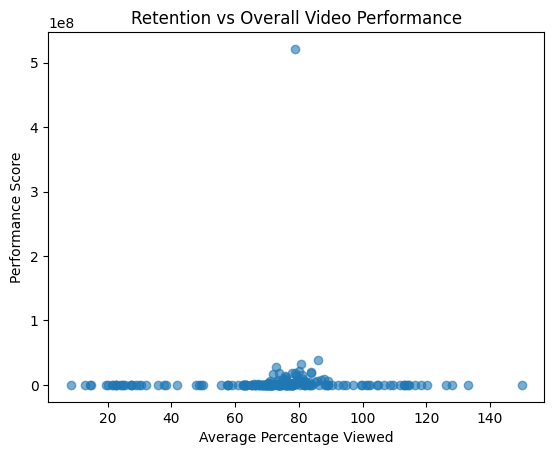

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    df_core["Average percentage viewed (%)"],
    df_core["performance_score"],
    alpha=0.6
)
plt.xlabel("Average Percentage Viewed")
plt.ylabel("Performance Score")
plt.title("Retention vs Overall Video Performance")
plt.show()

Videos with higher audience retention tend to perform better overall.

If the dots trend upwards from left to right, it means:

As retention increases,
Performance score also increases

This visually supports a key insight:

Keeping viewers watching is more important than just getting clicks.


#***Real-Time Trend Collection**

>## I collect real-time popular YouTube videos using the YouTube Data API and filter them for art-related content. This dataset is used to identify current trends and generate new video ideas.


## ==============================
## 9. YOUTUBE DATA API COLLECTION
## ==============================
## Collect trending and high-performing art videos using the YouTube Data API

In [ ]:
!pip install google-api-python-client

In [ ]:
import pandas as pd
from googleapiclient.discovery import build
API_KEY = "Your API key " #Sensitive credentials omitted for safety.

youtube = build( "youtube","v3",developerKey=API_KEY)

## ==============================
## 10. ART VIDEO FILTERING LOGIC
## ==============================
## Filter genuine art-making content using
## specific keywords .

In [ ]:
import pandas as pd
import re

queries = [
    "drawing tutorial",
    "how to draw",
    "sketchbook tour",
    "painting tutorial",
    "watercolor painting",
    "acrylic painting",
    "digital art tutorial",
    "procreate tutorial",
    "speedpaint",
    "art challenge",
    "portrait drawing",
    "anime drawing tutorial",
    "illustration process"
]

videos = []

for query in queries:
    search_request = youtube.search().list(
        part="snippet",
        q=query,
        type="video",
        relevanceLanguage="en",
        regionCode="US",
        maxResults=25,
        order="viewCount",
        videoCategoryId="26"  # Howto & Style, often better for tutorials
    )

    search_response = search_request.execute()

    video_ids = [
        item["id"]["videoId"]
        for item in search_response.get("items", [])
    ]

    if not video_ids:
        continue

    details_request = youtube.videos().list(
        part="snippet,statistics",
        id=",".join(video_ids)
    )

    details_response = details_request.execute()

    for item in details_response.get("items", []):
        snippet = item["snippet"]
        stats = item.get("statistics", {})

        videos.append({
            "query": query,
            "video_id": item["id"],
            "title": snippet.get("title", ""),
            "channel": snippet.get("channelTitle", ""),
            "description": snippet.get("description", ""),
            "published": snippet.get("publishedAt", ""),
            "views": int(stats.get("viewCount", 0)),
            "likes": int(stats.get("likeCount", 0)),
            "language": snippet.get("defaultAudioLanguage", snippet.get("defaultLanguage", "")),
        })

df = pd.DataFrame(videos)
df = df.drop_duplicates(subset="video_id")

In [ ]:
must_have_art_terms = [
    "draw", "drawing", "sketch", "sketchbook", "paint", "painting",
    "watercolor", "acrylic", "gouache", "portrait", "illustration",
    "procreate", "digital art", "speedpaint", "art tutorial",
    "how to draw", "anime drawing"
]

bad_terms = [
    "official video", "music video", "song", "lyrics", "mc ",
    "funk", "remix", "trailer", "teaser", "movie", "episode",
    "reaction", "gameplay", "minecraft", "gta", "roblox",
    "news", "shorts compilation"
]

def looks_english(text):
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return False

    ascii_letters = [c for c in letters if c.isascii()]
    return len(ascii_letters) / len(letters) >= 0.9

def is_real_art_video(row):
    text = f"{row['title']} {row['channel']} {row['description']}".lower()
    title = row["title"].lower()

    has_art = any(term in text for term in must_have_art_terms)
    has_bad = any(term in text for term in bad_terms)
    is_english = looks_english(row["title"] + " " + row["channel"])

    # Important: require the title itself to have an art-making term.
    title_has_art = any(term in title for term in must_have_art_terms)

    return has_art and title_has_art and not has_bad and is_english

art_df = df[df.apply(is_real_art_video, axis=1)].copy()

## ==============================
## 11. Ranking High-Performing Art Videos
## ==============================
## Rank high-performing art videos based
## on engagement and popularity metrics

In [ ]:
art_df = art_df.sort_values(
    by=["views", "likes"],
    ascending=False
).reset_index(drop=True)

art_df.insert(0, "rank", range(1, len(art_df) + 1))

result = art_df[[
    "rank", "title", "channel", "views", "likes", "published", "query"
]]

result.head(50)

## ==============================
## 12. LIMITATIONS & FUTURE WORK
## ==============================
## - YouTube API does not provide true global trends
## - Future versions could use ML models
##   for predictive performance scoring

# **12. Final Insights**
## This project shows how YouTube analytics can be turned into useful insights by cleaning data, analyzing video performance, finding common keywords, creating visualizations, and building a simple scoring system. The goal is to understand what makes videos perform well and use those patterns to evaluate future video ideas.